In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

In [2]:
PROJECT_ROOT = Path('../')
DATA_RAW     = PROJECT_ROOT / 'data' / 'raw'
DATA_OUT     = PROJECT_ROOT / 'data' / 'processed'

df = pd.read_csv(DATA_OUT / 'merged_nhanes.csv')
print(f"Loaded: {df.shape}")
df.head()

Loaded: (27493, 49)


,BMDBMIC,BMDSTATS,BMIARMC,BMIARML,BMIHEAD,BMIHIP,BMIHT,BMILEG,BMIRECUM,BMIWAIST,...,RIDRETH1,RIDRETH3,RIDSTATR,SDDSRVYR,SDMVPSU,SDMVSTRA,SEQN,cycle,diabetes,race_label
0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,5.0,6.0,2.0,12.0,2.0,173.0,130378.0,2021-2023,0.0,NH Asian
1,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.0,3.0,2.0,12.0,2.0,173.0,130379.0,2021-2023,0.0,NH White
2,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.0,2.0,2.0,12.0,1.0,174.0,130380.0,2021-2023,1.0,Other Hispanic
3,4.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,5.0,7.0,2.0,12.0,2.0,182.0,130381.0,2021-2023,0.0,Other/Multi
4,NaN,3.0,1.0,1.0,NaN,NaN,1.0,NaN,1.0,1.0,...,3.0,3.0,2.0,12.0,2.0,182.0,130382.0,2021-2023,0.0,NH White


In [3]:
missingness = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missingness_df = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_pct': missingness
})
print(missingness_df[missingness_df['missing_count'] > 0].round(2))


          missing_count  missing_pct
BMDBMIC           20252        73.66
BMDSTATS           4333        15.76
BMIARMC           26795        97.46
BMIARML           26806        97.50
BMIHEAD           27493       100.00
BMIHIP            26756        97.32
BMIHT             27188        98.89
BMILEG            26609        96.78
BMIRECUM          27432        99.78
BMIWAIST          26529        96.49
BMIWT             26560        96.61
BMXARMC            5447        19.81
BMXARML            5435        19.77
BMXBMI             5885        21.41
BMXHEAD           27113        98.62
BMXHIP            10855        39.48
BMXHT              5837        21.23
BMXLEG             9174        33.37
BMXRECUM          25569        93.00
BMXWAIST           6729        24.48
BMXWT              4664        16.96
DID040            24969        90.82
DID060            26723        97.20
DIQ010              767         2.79
DIQ050            24967        90.81
DIQ060U           26743        97.27
D

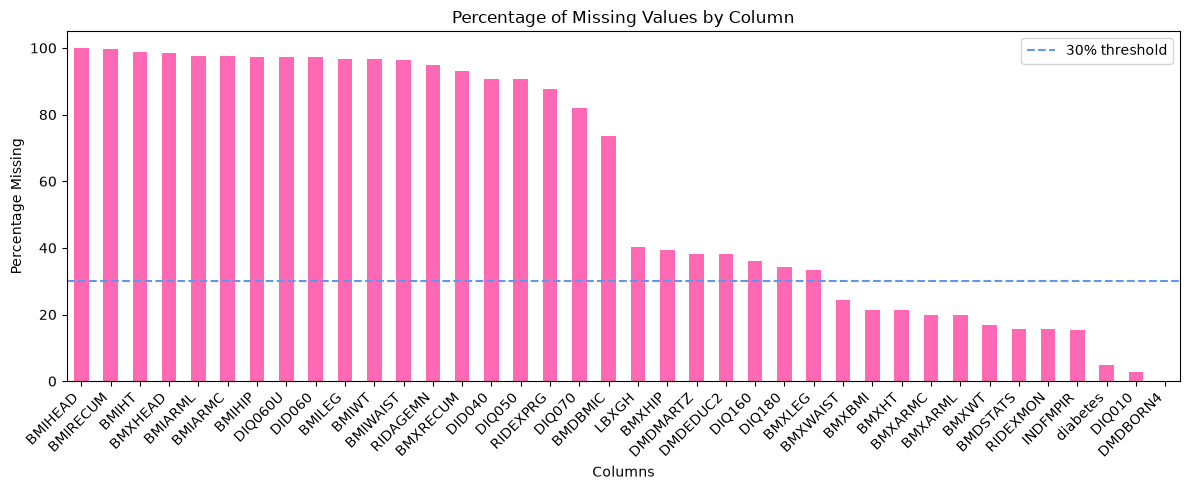

In [4]:
fig, ax = plt.subplots(figsize=(12, 5))
cols_with_missing = missingness[missingness > 0]
cols_with_missing.plot(kind='bar', ax=ax, color='hotpink')
ax.axhline(y = 30, color='cornflowerblue', linestyle="--", label='30% threshold')
ax.set_title('Percentage of Missing Values by Column')
ax.set_ylabel('Percentage Missing')
ax.set_xlabel('Columns')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../figures/missingness_bar_chart.png', dpi=300)
plt.show()

In [5]:
protect_cols = ['LBXGH'] #can't delete this column despite being above 30% missing since it's our target variable

drop_cols = missingness[missingness > 30].index.tolist()
drop_cols = [c for c in drop_cols if c  in df.columns and c not in protect_cols]

print(f"Dropping {len(drop_cols)} columns above 30% missing: {drop_cols}")
df = df.drop(columns=drop_cols)
print(f"Shape after dropping: {df.shape}")

df['cycle_2021'] = (df['cycle'] == '2021-2023').astype(int)
print(f"\nCycle distribution:")
print(df['cycle'].value_counts())

Dropping 25 columns above 30% missing: ['BMIHEAD', 'BMIRECUM', 'BMIHT', 'BMXHEAD', 'BMIARML', 'BMIARMC', 'BMIHIP', 'DIQ060U', 'DID060', 'BMILEG', 'BMIWT', 'BMIWAIST', 'RIDAGEMN', 'BMXRECUM', 'DID040', 'DIQ050', 'RIDEXPRG', 'DIQ070', 'BMDBMIC', 'BMXHIP', 'DMDMARTZ', 'DMDEDUC2', 'DIQ160', 'DIQ180', 'BMXLEG']
Shape after dropping: (27493, 24)

Cycle distribution:
cycle
2019-2020    15560
2021-2023    11933
Name: count, dtype: int64


In [6]:
df = df[df['RIDAGEYR'] >= 20].copy()
print(f"After adult filter: {df.shape}")

df = df[df['DIQ010'].isin([1, 2, 3])].copy()
print(f"After removing refused/unknown: {df.shape}")

print("\nDiabetes target distribution:")
print(df['diabetes'].value_counts(dropna=False))

df = df[df['diabetes'].isin([0, 1])].copy()
print(f"After dropping borderline: {df.shape}")
print(f"Class balance: {df['diabetes'].mean():.1%} diabetic")


After adult filter: (17041, 25)
After removing refused/unknown: (17033, 25)

Diabetes target distribution:
diabetes
0.0    14011
1.0     2490
NaN      532
Name: count, dtype: int64
After dropping borderline: (16501, 25)
Class balance: 15.1% diabetic


In [7]:
continuous_cols = ['LBXGH', 'BMXBMI', 'RIDAGEYR']
continuous_cols = [c for c in continuous_cols if c in df.columns]
categorical_cols = ['RIAGENDR', 'RIDRETH3']
keep_cols = continuous_cols + categorical_cols + ['diabetes', 'cycle_2021']
keep_cols = [c for c in keep_cols if c in df.columns]  # safety check
df_model = df[keep_cols].copy()

numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipeline, continuous_cols)
], remainder='passthrough')

transformed = preprocessor.fit_transform(df_model.drop(columns=['diabetes']))

remainder_cols = [c for c in df_model.columns if c not in continuous_cols + ['diabetes']]
final_cols = continuous_cols + remainder_cols

df_processed = pd.DataFrame(transformed, columns=final_cols)
df_processed = df_processed.apply(pd.to_numeric, errors='coerce')
df_processed['diabetes'] = df['diabetes'].values

print(f"Shape: {df_processed.shape}")
print(f"\nScaled feature stats:")
print(df_processed[continuous_cols].describe().round(3))
print(f"\nAny nulls remaining: {df_processed.isnull().sum().sum()}")
print(f"\nDtypes sample:")
print(df_processed.dtypes)


Shape: (16501, 7)

Scaled feature stats:
           LBXGH     BMXBMI   RIDAGEYR
count  16501.000  16501.000  16501.000
mean       0.000     -0.000     -0.000
std        1.000      1.000      1.000
min       -2.942     -2.716     -1.810
25%       -0.473     -0.611     -0.850
50%       -0.177     -0.158      0.111
75%        0.021      0.397      0.846
max       11.182      9.153      1.581

Any nulls remaining: 0

Dtypes sample:
LBXGH         float64
BMXBMI        float64
RIDAGEYR      float64
RIAGENDR      float64
RIDRETH3      float64
cycle_2021    float64
diabetes      float64
dtype: object


In [8]:
joblib.dump(preprocessor, DATA_OUT / 'preprocessor.pkl')
print("Saved preprocessor")

df_processed.to_csv(DATA_OUT / 'nhanes_clean.csv', index=False)
print("Saved nhanes_clean.csv")
print(f"Shape: {df_processed.shape}")

Saved preprocessor
Saved nhanes_clean.csv
Shape: (16501, 7)
